In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import metrics
import re
import nltk

In [61]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('D:/data/Spam/SPAM text message 20170820 - Data.csv')

In [62]:
# Replace 'ham' and 'spam' labels with numeric values (0 and 1)
df['Category'] = df['Category'].replace({'ham': 0, 'spam': 1})

C:\Users\hp\AppData\Local\Temp\ipykernel_6540\1310079581.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Category'] = df['Category'].replace({'ham': 0, 'spam': 1})


  category  number
0     spam     747
1      ham    4825


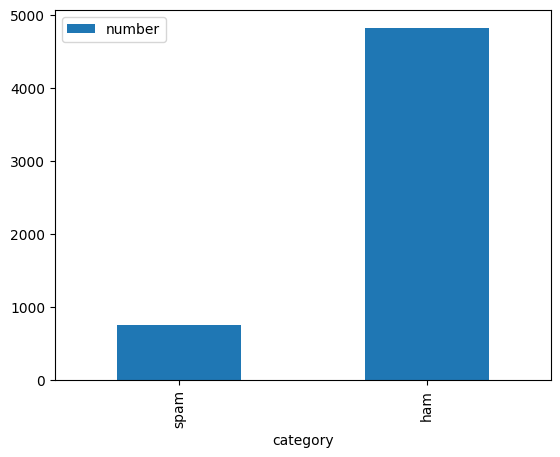

In [74]:
# gain insight from data
data = {'category': ['spam', 'ham'],
        'number': [len(df.loc[df.Category==1]), len(df.loc[df.Category==0])]
        }  
df_count = pd.DataFrame(data,columns=['category', 'number'])
print (df_count)

df_count.plot(x ='category', y='number', kind = 'bar')
plt.show()


In [64]:
# Initialize the PorterStemmer for stemming
stemmer = PorterStemmer()

# Load the list of stopwords from NLTK
sw = stopwords.words()

In [65]:
# Create an empty list to store the cleaned and processed text
corpus = []

# Loop through each message in the dataset for text preprocessing
for w in df['Message']:
    # Remove non-alphabetical characters using regex
    msg = re.sub('[^a-zA-Z]', ' ', w)
    # Convert all text to lowercase
    msg = msg.lower()
    # Split the text into individual words
    msg = msg.split()
    # Perform stemming and remove stopwords from the message
    msg = [stemmer.stem(word) for word in msg if word not in stopwords.words('english')]
    # Rejoin the processed words back into a single string
    msg = ' '.join(msg)
    # Append the cleaned message to the corpus
    corpus.append(msg)

In [66]:
# Create a new DataFrame with cleaned messages and their corresponding categories
df2 = pd.DataFrame({'Message': corpus, 'Category': df.Category})

In [67]:
# Initialize the TfidfVectorizer to convert text into numerical vectors
tf = TfidfVectorizer()

# Transform the processed corpus into a numerical feature matrix
X = tf.fit_transform(corpus).toarray()

# Define the target variable (Category) as y
y = df['Category']

In [68]:
# Use SMOTE to balance the dataset by oversampling the minority class
smote = SMOTE(random_state=42)
X_resample, y_resample = smote.fit_resample(X, y)

In [69]:
# Split the resampled data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resample, y_resample, test_size=0.20, random_state=0)

In [84]:
model = SVC(random_state=42)
model.fit(X_train, y_train)

SVC(random_state=42)

In [85]:
# Make predictions on the testing set
y_pred = model.predict(X_test)

# Compute the confusion matrix to evaluate model performance
confusion_m = metrics.confusion_matrix(y_test, y_pred)
print(confusion_m)

[[940   2]
 [  1 987]]


In [86]:
# Print a detailed classification report (precision, recall, F1-score, etc.)
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       942
           1       1.00      1.00      1.00       988

    accuracy                           1.00      1930
   macro avg       1.00      1.00      1.00      1930
weighted avg       1.00      1.00      1.00      1930



In [87]:
# Perform 10-fold cross-validation and compute the F1 score
cvs = cross_val_score(model, X_test, y_test, cv=10, scoring='f1')
print(cvs)  # Print F1 scores for each fold
print(cvs.mean())  # Print the average F1 score

[0.99492386 0.97938144 0.97409326 0.98979592 0.97461929 0.97938144
 0.99492386 0.99492386 0.99497487 0.98989899]
0.9866916796429
